# 📊 Customer Churn Prediction using Machine Learning

## 📌 Problem Statement

Customer churn refers to customers leaving a company and discontinuing its services.

Banks lose a significant amount of revenue when valuable customers leave. Predicting customer churn in advance helps the bank identify high-risk customers and take proactive actions to retain them.

## 🎯 Objective

Develop a Machine Learning model that predicts whether a customer will churn based on customer demographics, account details, and banking behavior.

## 💼 Business Impact

Instead of waiting for customers to leave, the bank can:

- Offer personalized discounts
- Improve customer support
- Launch loyalty programs
- Increase customer retention
- Reduce financial losses

# 📚 Step 1 : Import Required Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Plot Style
sns.set_style("whitegrid")

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


# Load Dataset

In [7]:
df = pd.read_csv("../data/Bank Customer Churn Prediction.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [8]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("Dataset Shape :", df.shape)

print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records :", df.duplicated().sum())

Dataset Shape : (10000, 12)

Rows : 10000
Columns : 12

Column Names
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 n

In [11]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


# 🧹 Data Quality Check

Before building any Machine Learning model, it is important to examine the quality of the dataset.

In this step, we will:
- Check for missing values
- Check duplicate records
- Identify data types
- Find unique values
- Understand categorical and numerical features

In [12]:
# ==========================================================
# Data Quality Check
# ==========================================================

print("=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("Duplicate Records")
print("=" * 60)
print(df.duplicated().sum())

print("\n" + "=" * 60)
print("Data Types")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("Unique Values")
print("=" * 60)
print(df.nunique())

Missing Values
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicate Records
0

Data Types
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Unique Values
customer_id         10000
credit_score          460
country                 3
gender                  2
age                    70
tenure                 11
balance              6382
products_number         4
credit_card             2
active_member           2
estimated_salary     9999
churn                   

# 📂 Feature Categorization

For better analysis, we separate the dataset into:

- Numerical Features
- Categorical Features

This helps us perform appropriate visualizations and preprocessing.

In [13]:
# ==========================================================
# Separate Numerical and Categorical Features
# ==========================================================

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Features")
print(numerical_columns.tolist())

print("\nCategorical Features")
print(categorical_columns.tolist())

Numerical Features
['customer_id', 'credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Categorical Features
['country', 'gender']


## 📌 Observations

- The dataset contains **10,000 customer records**.
- No missing values were found.
- No duplicate records were found.
- The dataset contains both numerical and categorical features.
- The target variable is **Exited**, where:
  - **1 = Customer Churned**
  - **0 = Customer Retained**

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the distribution of data, identify patterns, detect outliers, and analyze relationships between variables.

In this section, we will visualize both numerical and categorical features to gain meaningful insights.

## 📌 Distribution of Target Variable (Exited)

The target variable **Exited** indicates whether a customer has left the bank.

- 0 → Customer Retained
- 1 → Customer Churned

This visualization helps us understand the class distribution.

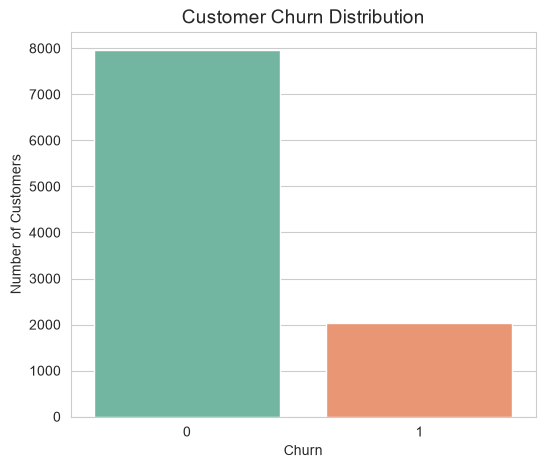


Percentage Distribution
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [16]:
# ==========================================================
# Distribution of Target Variable (Churn)
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='churn',
    hue='churn',
    palette='Set2',
    legend=False
)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

print("\nPercentage Distribution")
print(df['churn'].value_counts(normalize=True) * 100)

## 📌 Observation

- The target variable is **churn**.
- Customers with **churn = 0** are retained customers.
- Customers with **churn = 1** have left the bank.
- The distribution helps us identify whether the dataset is balanced or imbalanced.

# 📈 Distribution of Numerical Features

In this section, we analyze the distribution of all numerical features.

This helps us understand:
- Data distribution
- Skewness
- Outliers
- Feature ranges

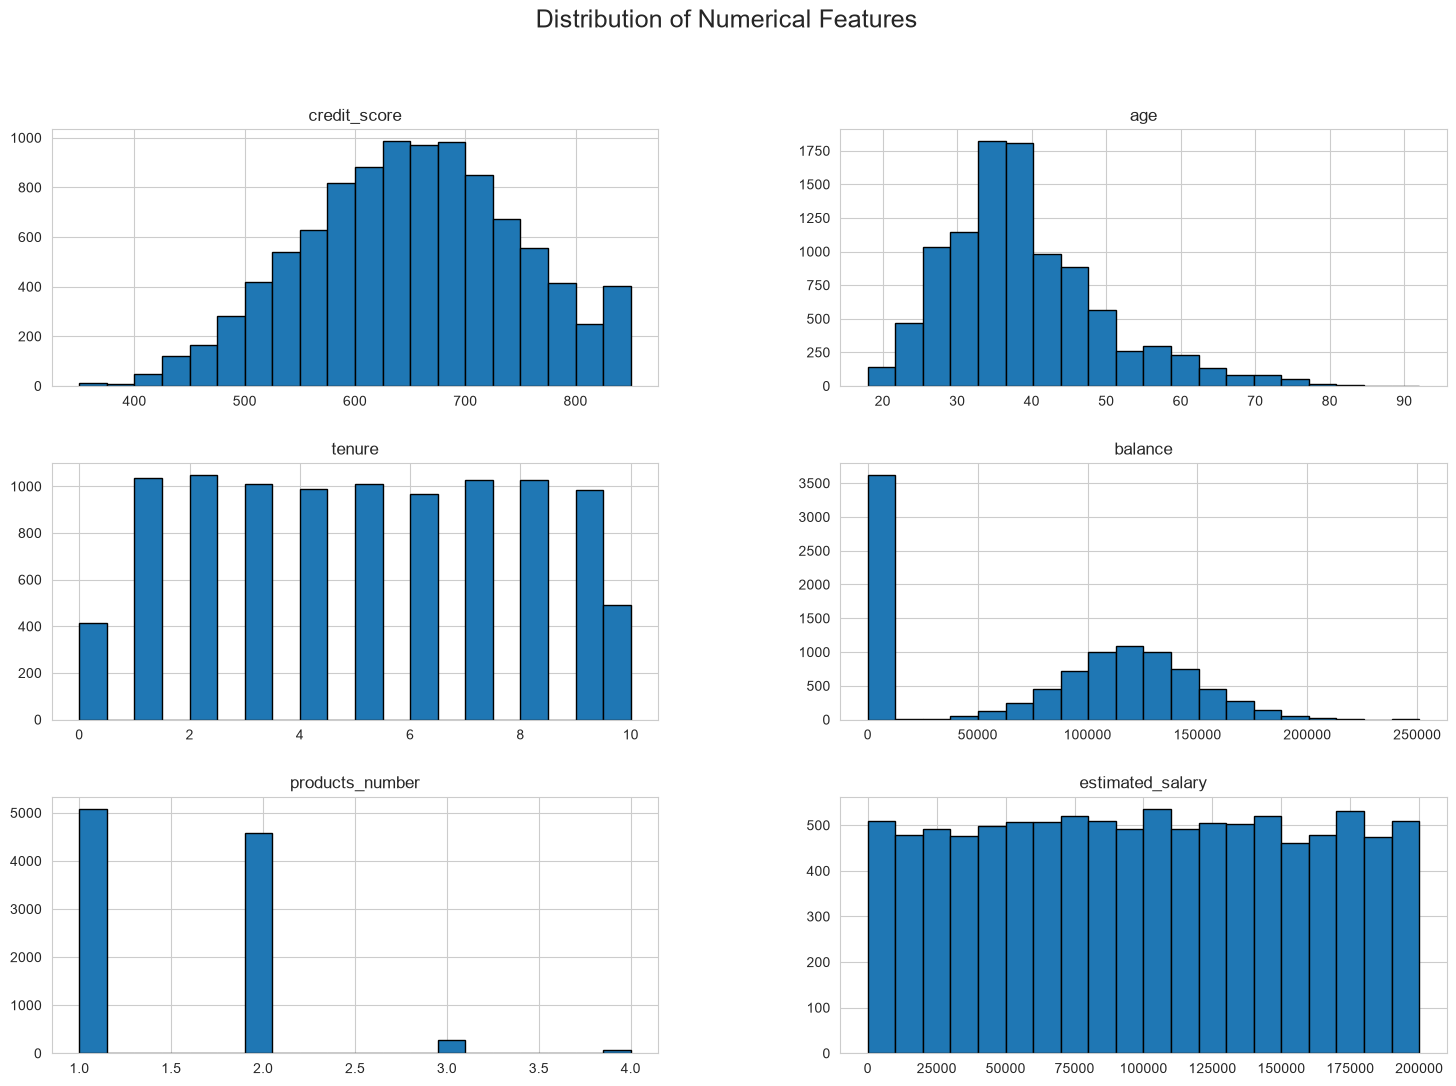

In [17]:
# ==========================================================
# Distribution of Numerical Features
# ==========================================================

# Select Numerical Columns
numerical_columns = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'estimated_salary'
]

# Plot Histograms
df[numerical_columns].hist(
    figsize=(18,12),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.show()

## 📌 Observation

- Credit Score appears approximately normally distributed.
- Age is slightly right-skewed.
- Balance contains customers with both low and high account balances.
- Estimated Salary is almost uniformly distributed.
- These visualizations help us identify skewness and unusual data patterns.

# 📊 Distribution of Categorical Features

Now we analyze categorical variables to understand the customer demographics.

Features analyzed:
- Country
- Gender
- Credit Card
- Active Member

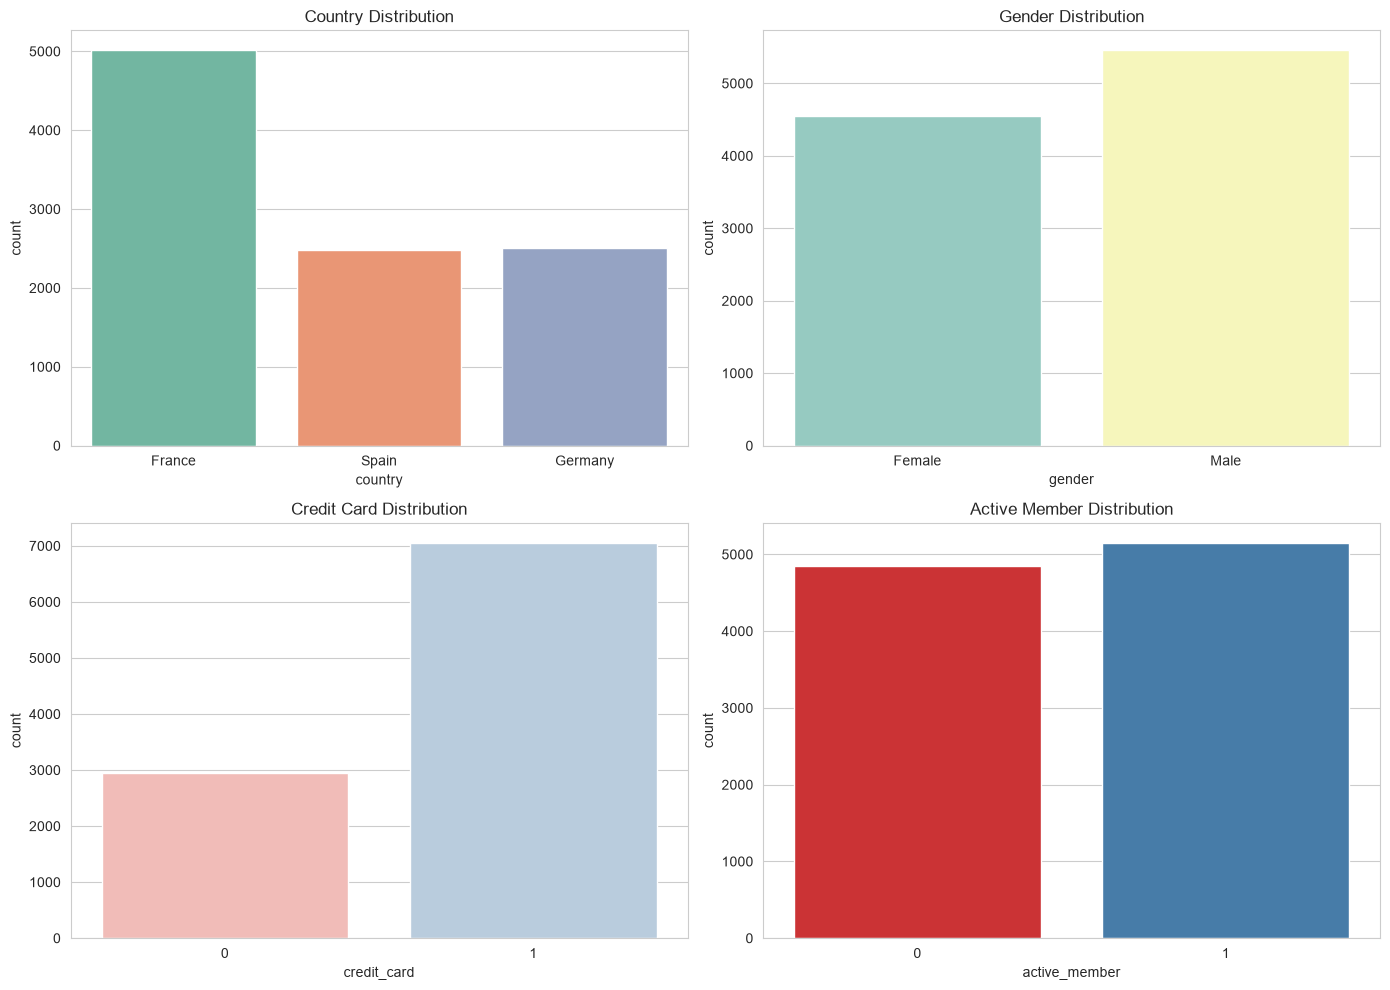

In [18]:
# ==========================================================
# Distribution of Categorical Features
# ==========================================================

fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.countplot(data=df, x='country', ax=axes[0,0], hue='country', palette='Set2', legend=False)
axes[0,0].set_title("Country Distribution")

sns.countplot(data=df, x='gender', ax=axes[0,1], hue='gender', palette='Set3', legend=False)
axes[0,1].set_title("Gender Distribution")

sns.countplot(data=df, x='credit_card', ax=axes[1,0], hue='credit_card', palette='Pastel1', legend=False)
axes[1,0].set_title("Credit Card Distribution")

sns.countplot(data=df, x='active_member', ax=axes[1,1], hue='active_member', palette='Set1', legend=False)
axes[1,1].set_title("Active Member Distribution")

plt.tight_layout()

plt.show()

## 📌 Observation

- Customers belong to multiple countries.
- Male and female customers are almost equally distributed.
- Most customers own a credit card.
- The number of active and inactive members can be compared through the visualization.

# 📊 Relationship Between Features and Customer Churn

In this section, we analyze how different customer attributes influence churn.

The objective is to identify which features have the strongest impact on customer retention.

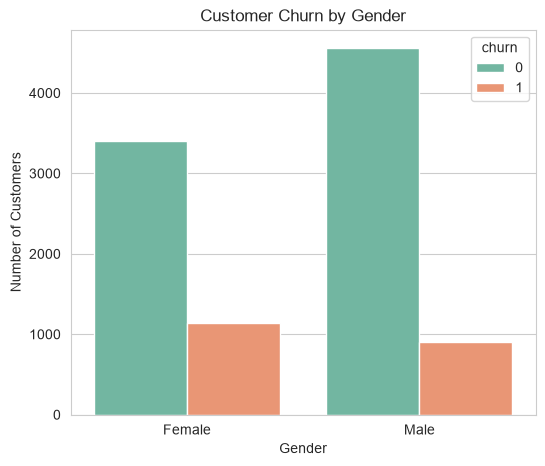

In [19]:
# ==========================================================
# Churn vs Gender
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='gender',
    hue='churn',
    palette='Set2'
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## 📌 Observation

- Compare churn rates between male and female customers.
- Identify whether one gender has a higher tendency to churn.

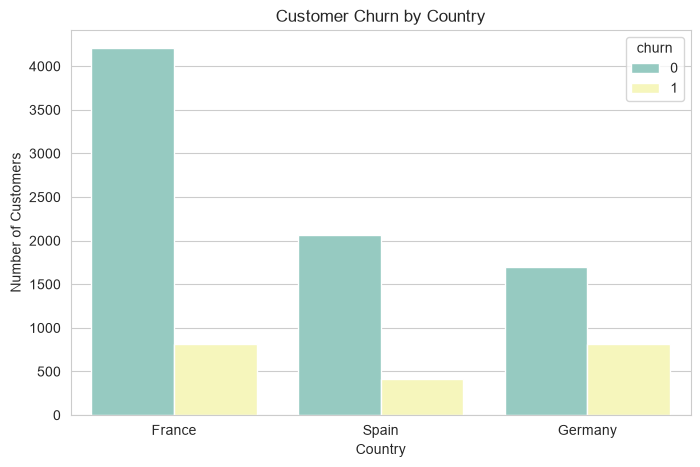

In [20]:
# ==========================================================
# Churn vs Country
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='country',
    hue='churn',
    palette='Set3'
)

plt.title("Customer Churn by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.show()

## 📌 Observation

- Compare customer churn across different countries.
- Identify the country with the highest churn rate.

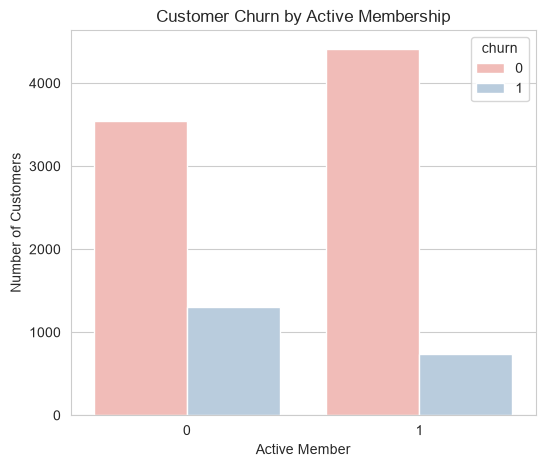

In [21]:
# ==========================================================
# Churn vs Active Member
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='active_member',
    hue='churn',
    palette='Pastel1'
)

plt.title("Customer Churn by Active Membership")
plt.xlabel("Active Member")
plt.ylabel("Number of Customers")

plt.show()

## 📌 Observation

- Compare churn between active and inactive customers.
- Analyze whether active membership reduces churn.

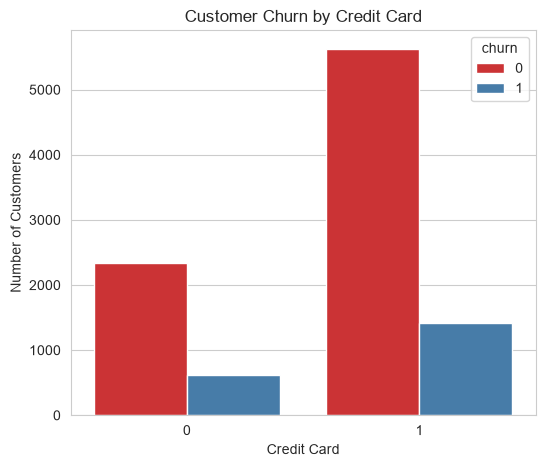

In [22]:
# ==========================================================
# Churn vs Credit Card
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='credit_card',
    hue='churn',
    palette='Set1'
)

plt.title("Customer Churn by Credit Card")
plt.xlabel("Credit Card")
plt.ylabel("Number of Customers")

plt.show()

## 📌 Observation

- Analyze whether owning a credit card influences customer churn.

# 📊 Relationship Between Numerical Features and Customer Churn

In this section, we analyze how numerical features influence customer churn.

We compare the distribution of numerical features for churned and retained customers using boxplots.

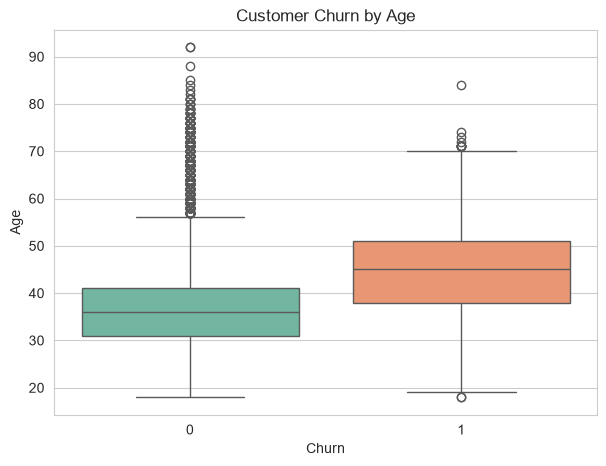

In [23]:
# ==========================================================
# Churn vs Age
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='churn',
    y='age',
    hue='churn',
    palette='Set2',
    legend=False
)

plt.title("Customer Churn by Age")
plt.xlabel("Churn")
plt.ylabel("Age")

plt.show()

## 📌 Observation

- Compare the age distribution of churned and retained customers.
- Check whether older customers are more likely to leave the bank.
- Identify the presence of outliers.

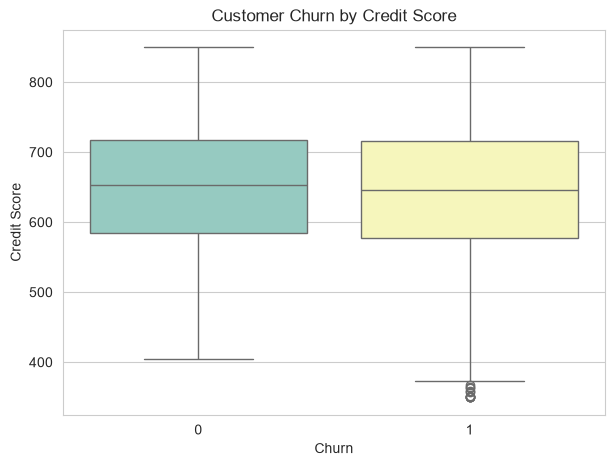

In [24]:
# ==========================================================
# Churn vs Credit Score
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='churn',
    y='credit_score',
    hue='churn',
    palette='Set3',
    legend=False
)

plt.title("Customer Churn by Credit Score")
plt.xlabel("Churn")
plt.ylabel("Credit Score")

plt.show()

## 📌 Observation

- Compare credit scores of churned and retained customers.
- Analyze whether lower credit scores contribute to churn.

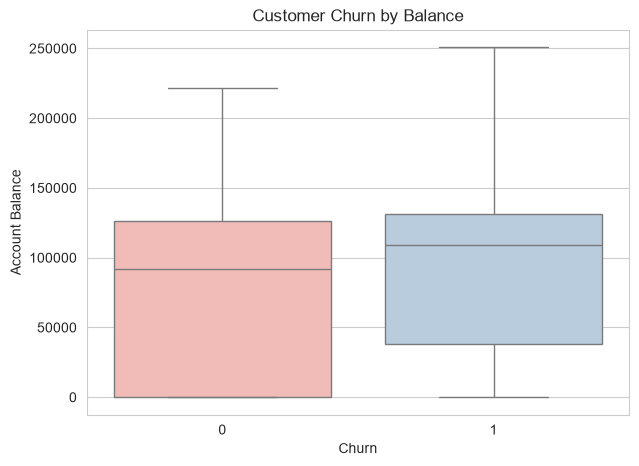

In [25]:
# ==========================================================
# Churn vs Balance
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='churn',
    y='balance',
    hue='churn',
    palette='Pastel1',
    legend=False
)

plt.title("Customer Churn by Balance")
plt.xlabel("Churn")
plt.ylabel("Account Balance")

plt.show()

## 📌 Observation

- Analyze whether customers with higher account balances tend to churn more.
- Identify balance-related outliers.

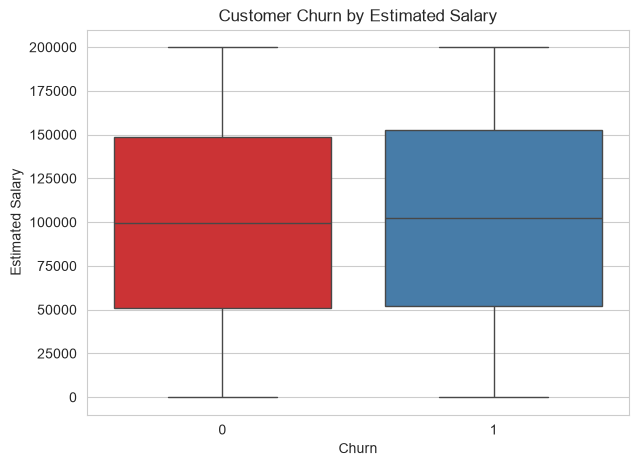

In [26]:
# ==========================================================
# Churn vs Estimated Salary
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='churn',
    y='estimated_salary',
    hue='churn',
    palette='Set1',
    legend=False
)

plt.title("Customer Churn by Estimated Salary")
plt.xlabel("Churn")
plt.ylabel("Estimated Salary")

plt.show()

## 📌 Observation

- Compare salary distributions between churned and retained customers.
- Determine whether salary significantly influences churn.

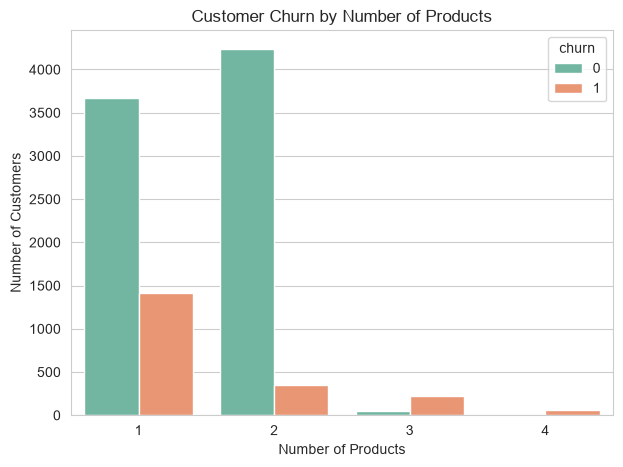

In [27]:
# ==========================================================
# Churn vs Products Number
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='products_number',
    hue='churn',
    palette='Set2'
)

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.show()

## 📌 Observation

- Compare churn across different product counts.
- Analyze whether customers with more products are more loyal.

# 🔥 Correlation Analysis

Correlation analysis helps us understand the relationship between numerical features.

A correlation value ranges from **-1 to +1**:

- **+1** → Strong Positive Correlation
- **0** → No Correlation
- **-1** → Strong Negative Correlation

This helps us identify important features for model building.

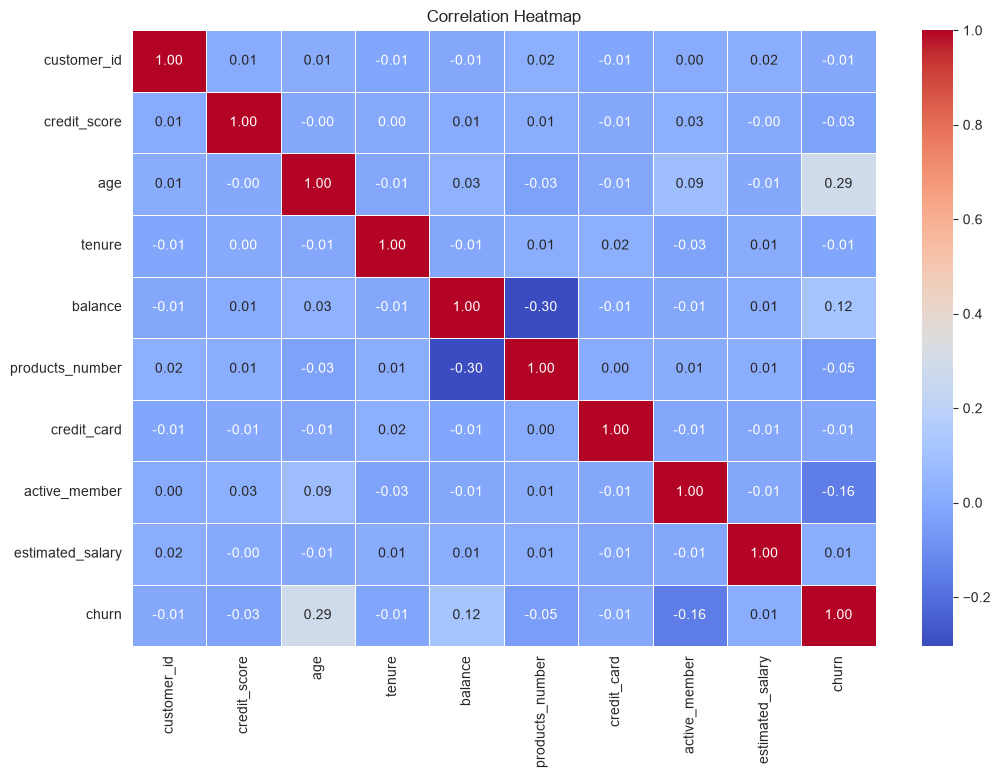

In [28]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## 📌 Observation

- Identify features that have a strong correlation with churn.
- Highly correlated features may significantly influence customer churn.
- Features with very low correlation may contribute less to prediction.

# 📦 Outlier Detection

Outliers are extreme values that differ significantly from the rest of the data.

Boxplots help visualize these unusual observations.

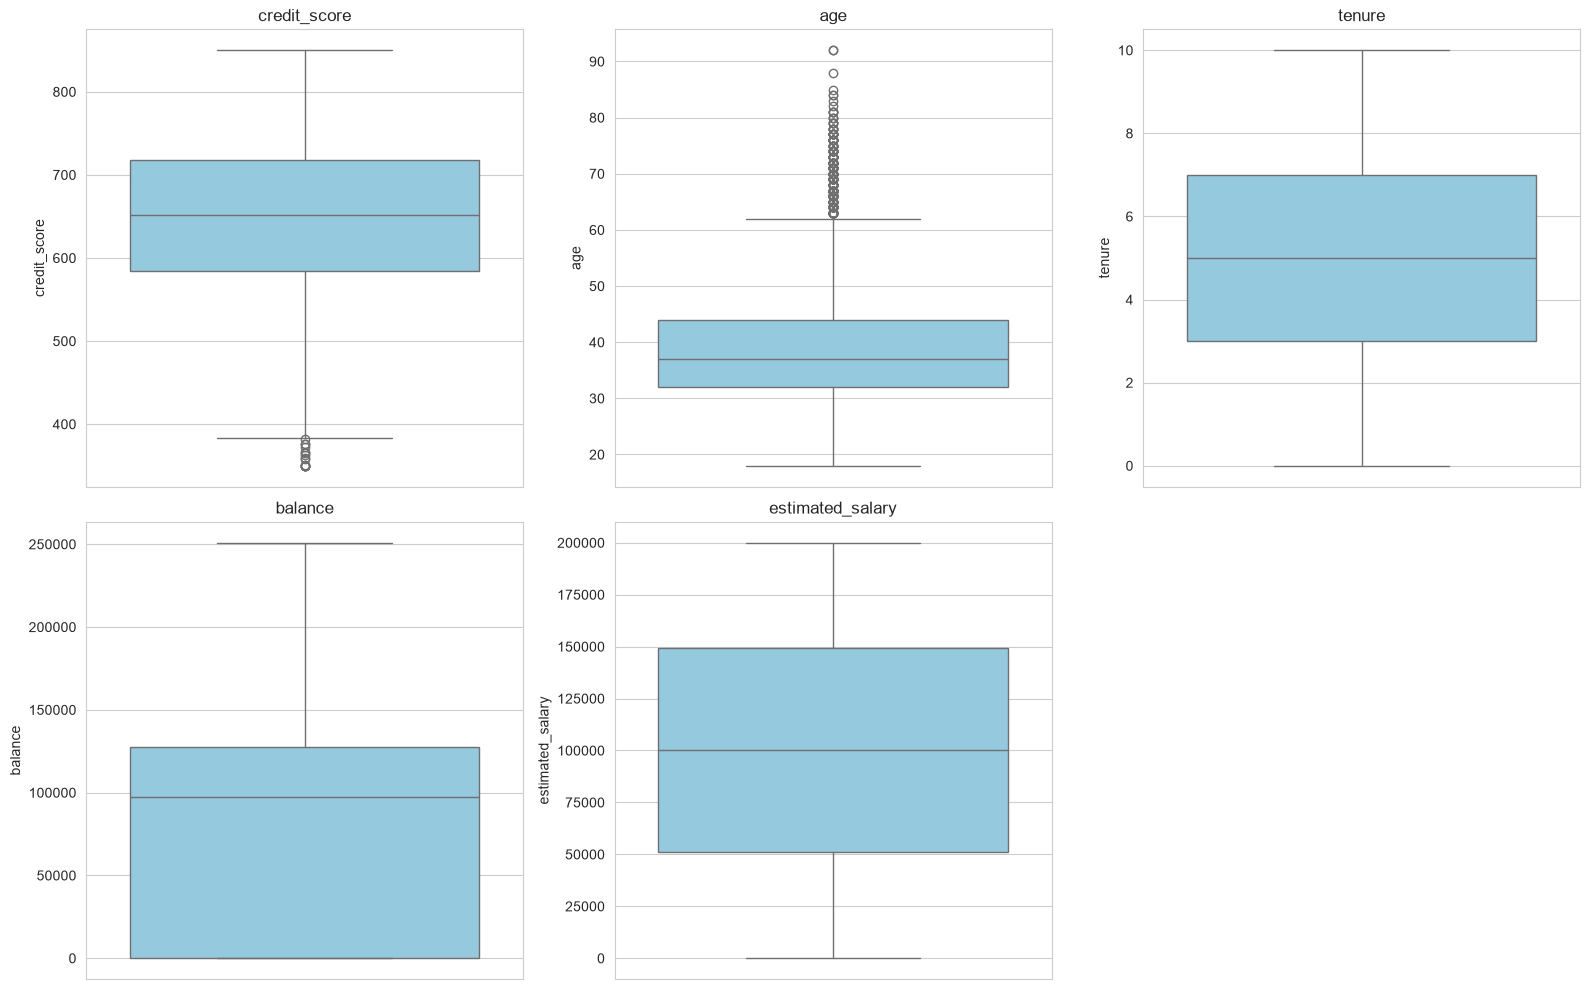

In [29]:
# ==========================================================
# Outlier Detection
# ==========================================================

numerical_columns = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'estimated_salary'
]

plt.figure(figsize=(16,10))

for i, column in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(
        y=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()

plt.show()

## 📌 Observation

- Some numerical features contain outliers.
- These outliers should be analyzed before model training.
- Tree-based algorithms are generally less affected by outliers.

# 📝 Exploratory Data Analysis Summary

### Key Insights

- Most customers are retained, while a smaller percentage have churned.
- Age appears to influence customer churn.
- Customers with different product counts show different churn behavior.
- Active members tend to churn less frequently.
- Credit score and balance may influence customer retention.
- Some numerical features contain outliers.
- Correlation analysis highlights the most influential variables for prediction.

These insights will guide the preprocessing and model-building stages.

# ⚙️ Data Preprocessing

Machine Learning models cannot directly work with raw data.

In this stage, we prepare the dataset by:

- Removing unnecessary columns
- Encoding categorical variables
- Splitting features and target
- Splitting training and testing data
- Scaling numerical features

In [30]:
# ==========================================================
# Import Libraries for Data Preprocessing
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


# 🗑️ Drop Unnecessary Columns

The **customer_id** is only a unique identifier.

It does not contribute to predicting customer churn, so we remove it before training the model.

In [31]:
# ==========================================================
# Drop Customer ID
# ==========================================================

df.drop(columns=['customer_id'], inplace=True)

print("customer_id removed successfully ✅")

df.head()

customer_id removed successfully ✅


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 🔄 Label Encoding

Machine Learning algorithms work with numerical values.

We convert categorical features into numerical format using Label Encoding.

Features to encode:

- country
- gender

In [32]:
# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

df['country'] = encoder.fit_transform(df['country'])

df['gender'] = encoder.fit_transform(df['gender'])

print("Categorical Features Encoded Successfully ✅")

df.head()

Categorical Features Encoded Successfully ✅


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


# 🎯 Feature Selection

Separate the dataset into:

- Features (X)
- Target Variable (y)

Target Variable:

- churn

In [33]:
# ==========================================================
# Separate Features and Target Variable
# ==========================================================

X = df.drop('churn', axis=1)

y = df['churn']

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape :", y.shape)

Feature Matrix Shape : (10000, 10)
Target Variable Shape : (10000,)


# ✂️ Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Training data is used to train the model, while testing data evaluates model performance.

In [34]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (8000, 10)
Testing Features : (2000, 10)
Training Labels : (8000,)
Testing Labels : (2000,)


# 📏 Feature Scaling

Different numerical features have different ranges.

Feature Scaling standardizes the values so that Machine Learning algorithms perform better.

In [35]:
# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully ✅")

Feature Scaling Completed Successfully ✅


# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully ✅")

# 🤖 Machine Learning Model Building

In this phase, multiple Machine Learning algorithms are trained and evaluated.

The objective is to compare their performance and select the best model for customer churn prediction.

In [37]:
# ==========================================================
# Import Machine Learning Algorithms
# ==========================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

print("Machine Learning Libraries Imported Successfully ✅")

Machine Learning Libraries Imported Successfully ✅


# 🤖 Train Multiple Machine Learning Models

In this section, we train multiple classification algorithms and compare their performance.

Models Used:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Gradient Boosting

In [38]:
# ==========================================================
# Create Machine Learning Models
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)

}

print("Models Created Successfully ✅")

Models Created Successfully ✅


# 📊 Model Training and Evaluation

Each model is trained using the training dataset.

Performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

In [39]:
# ==========================================================
# Train and Evaluate All Models
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Store Results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

print("All Models Trained Successfully ✅")

All Models Trained Successfully ✅


# 📈 Model Comparison

The performance of all trained models is summarized in the table below.

This comparison helps us identify the best-performing algorithm for customer churn prediction.

In [40]:
# ==========================================================
# Compare Machine Learning Models
# ==========================================================

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]

)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8675,0.788618,0.476658,0.594181,0.722008
1,Random Forest,0.8645,0.785714,0.459459,0.579845,0.713722
2,KNN,0.8350,0.662447,0.385749,0.487578,0.667765
3,Logistic Regression,0.8050,0.585859,0.142506,0.229249,0.558384
4,Decision Tree,0.7755,0.451163,0.476658,0.463560,0.664255


## 📌 Observation

- Compare the performance of all machine learning models.
- Identify the model with the highest Accuracy and F1 Score.
- Select the best-performing model for deployment.

# 🏆 Best Model Selection

After evaluating all machine learning models, we select the model with the highest performance.

The best model will be used for:
- Hyperparameter Tuning
- Model Saving
- Deployment

In [41]:
# ==========================================================
# Best Performing Model
# ==========================================================

best_model = results_df.iloc[0]

print("🏆 Best Model")
print(best_model)

🏆 Best Model
Model        Gradient Boosting
Accuracy                0.8675
Precision             0.788618
Recall                0.476658
F1 Score              0.594181
ROC-AUC               0.722008
Name: 4, dtype: object


# 📋 Classification Report

The Classification Report provides detailed evaluation metrics including:

- Precision
- Recall
- F1 Score
- Support

These metrics help evaluate model performance for each class.

In [42]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

# Get the best model object
best_model_name = results_df.iloc[0]["Model"]
best_model_object = models[best_model_name]

# Predict using the best model
y_pred = best_model_object.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



# 📊 Confusion Matrix

A Confusion Matrix shows how well the model classifies customers into:

- True Positive
- True Negative
- False Positive
- False Negative

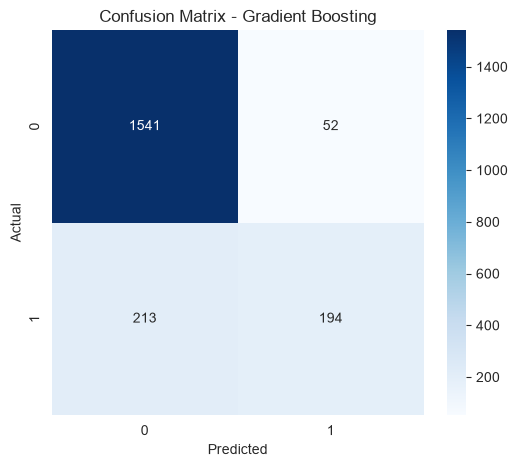

In [43]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 📈 ROC Curve

The ROC Curve evaluates the model's ability to distinguish between churned and retained customers.

A higher Area Under the Curve (AUC) indicates better model performance.

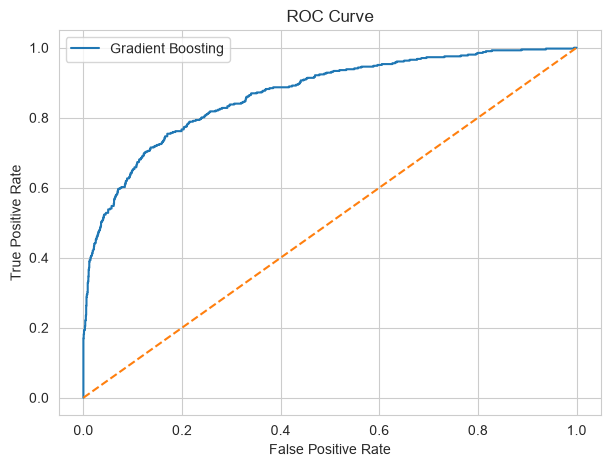

In [44]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

# Probability predictions
y_prob = best_model_object.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"{best_model_name}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ⭐ Feature Importance

Feature Importance helps identify which variables contribute the most to customer churn prediction.

This analysis improves model interpretability and business understanding.

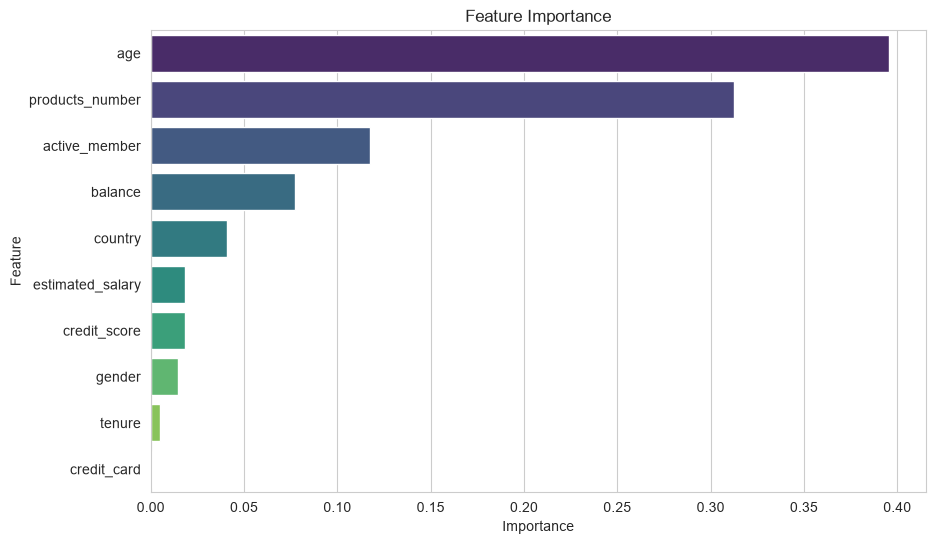

In [45]:
# ==========================================================
# Feature Importance
# ==========================================================

# Only tree-based models support feature_importances_
if hasattr(best_model_object, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model_object.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature",
        palette="viridis"
    )

    plt.title("Feature Importance")

    plt.show()

else:
    print(f"{best_model_name} does not provide feature importance.")

# ⚙️ Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best combination of parameters for a Machine Learning model.

In this project, we optimize the **Random Forest Classifier** using GridSearchCV to improve prediction performance.

In [46]:
# ==========================================================
# Hyperparameter Tuning - Random Forest
# ==========================================================

from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]

}

grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

print("Best Parameters")
print(grid_search.best_params_)

print("\nBest Accuracy")
print(grid_search.best_score_)

Best Parameters
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Accuracy
0.8636250000000001


# 🌳 Best Random Forest Model

The optimized Random Forest model obtained from GridSearchCV is used for final prediction and deployment.

In [47]:
# ==========================================================
# Best Random Forest Model
# ==========================================================

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("Final Accuracy")

print(accuracy_score(y_test, y_pred))

Final Accuracy
0.863


# 💾 Save Machine Learning Model

The trained model is saved using Joblib.

The saved model can later be loaded into the Flask application without retraining.

In [48]:
# ==========================================================
# Save Model
# ==========================================================

import joblib

joblib.dump(best_rf, "../models/churn_prediction_model.pkl")

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


In [49]:
# ==========================================================
# Save Scaler
# ==========================================================

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler Saved Successfully ✅")

Scaler Saved Successfully ✅


In [50]:
# ==========================================================
# Save Label Encoder
# ==========================================================

joblib.dump(encoder, "../models/label_encoder.pkl")

print("Label Encoder Saved Successfully ✅")

Label Encoder Saved Successfully ✅


# ==========================================================
# Save Label Encoder
# ==========================================================

joblib.dump(encoder, "../models/label_encoder.pkl")

print("Label Encoder Saved Successfully ✅")

# 🧪 Testing Saved Model

Before deployment, we load the saved model and make predictions on sample customer data.

This verifies that the saved model works correctly outside the training environment.

In [51]:
# ==========================================================
# Load Saved Model
# ==========================================================

import joblib

model = joblib.load("../models/churn_prediction_model.pkl")

scaler = joblib.load("../models/scaler.pkl")

print("Model Loaded Successfully ✅")

Model Loaded Successfully ✅


In [52]:
# ==========================================================
# Predict Single Customer
# ==========================================================

sample_customer = [[
    650,        # Credit Score
    0,          # Country (Encoded)
    1,          # Gender (Male=1, Female=0)
    35,         # Age
    5,          # Tenure
    65000,      # Balance
    2,          # Products
    1,          # Credit Card
    1,          # Active Member
    80000       # Estimated Salary
]]

sample_customer = scaler.transform(sample_customer)

prediction = model.predict(sample_customer)

if prediction[0] == 1:
    print("⚠ Customer is likely to Churn")
else:
    print("✅ Customer is likely to Stay")

✅ Customer is likely to Stay


# ⭐ Business Insights

The model identified the following important features:

- Age
- Balance
- Number of Products
- Active Member
- Credit Score

These variables contribute the most to customer churn prediction.

# 🚀 Future Scope

Possible improvements include:

- Real-time prediction API
- Customer retention dashboard
- Email alerts for high-risk customers
- SHAP Explainability
- Deep Learning Model
- Cloud Deployment

# 📚 References

- Kaggle Bank Customer Churn Dataset
- Scikit-Learn Documentation
- XGBoost Documentation
- Flask Documentation
- Pandas Documentation

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.863
Precision: 0.7854077253218884
Recall   : 0.44963144963144963
F1 Score : 0.571875
ROC AUC  : 0.7091220650542684
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

[[1543   50]
 [ 224  183]]
